# Análise do SomaVetor

In [15]:
def soma_vetor(vetor):
    soma = 0
    for i in range(len(vetor)):
        soma = soma + vetor[i]
    return soma


In [16]:
import vetor
vetor = vetor.gerar_aleatorio(5)
print(vetor)
print(f"minha versão: {soma_vetor(vetor)}")
print(f"versão python:{sum(vetor)}")

[50, 84, 43, 74, 67]
minha versão: 318
versão python:318


| Linha | Operações | Execuções | Complexidade |
|:-----:|----------|:---------:|:------------:|
|   1    |     1     |    1       |        1      |
|    2   |      1    |     n      |         n     |
|     3  |       3   |      n     |          3n    |
|     4  |       1   |      1     |            1  |



Somando tudo chegaríamos na função **T(n) = 4n + 2** uma função linear


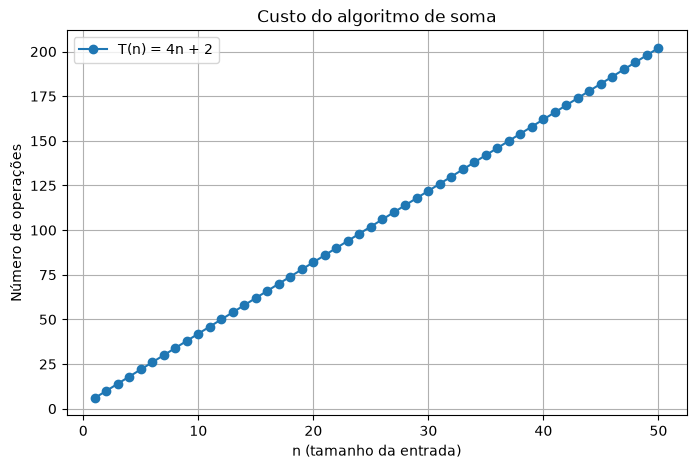

In [17]:
import matplotlib.pyplot as plt
import numpy as np


n = np.arange(1, 51)          # n de 1 a 50
T = 4 * n + 2

plt.figure(figsize=(8, 5))
plt.plot(n, T, marker='o', label='T(n) = 4n + 2')
plt.xlabel('n (tamanho da entrada)')
plt.ylabel('Número de operações')
plt.title('Custo do algoritmo de soma')
plt.grid(True)
plt.legend()
plt.show()

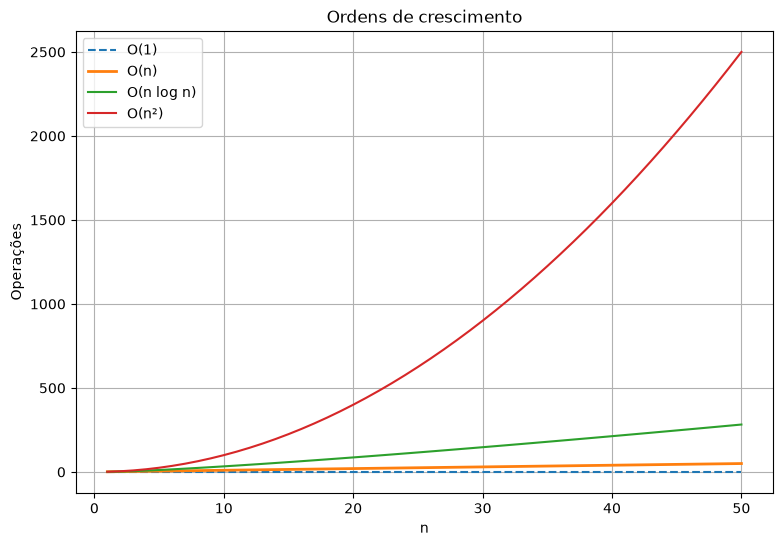

In [18]:
n = np.arange(1, 51)

plt.figure(figsize=(9, 6))
plt.plot(n, np.ones_like(n), label='O(1)',  linestyle='--')
plt.plot(n, n,              label='O(n)',  linewidth=2)
plt.plot(n, n * np.log2(n), label='O(n log n)')
plt.plot(n, n**2,           label='O(n²)')
plt.xlabel('n')
plt.ylabel('Operações')
plt.title('Ordens de crescimento')
plt.legend()
plt.grid(True)
plt.show()

# Casos

Até agora não estávamos muito preocupados com analisar os melhores e os piores casos desses algoritmos até porque o soma vetor não engloba isso. Mas a partir de agora vamos começar a pensar em  como esses algoritmos se comportam quando mudamos a organização com que os dados de entrada aparecem,detalhe importante: não estamos falando na variação do tamanho da entrada em si e sim na forma com que a entrada se organiza, ela está crescente? decrescente?não crescente? não decrescente? (esses últimos 2 permitem uma repetição de números nos vetores)

# Análise ArrayMax

In [19]:
# Vamos utilizar o mesmo vetor que foi utilizado anteriormente
def array_max(vetor):
    current_max = vetor[0]
    for i in range(1,len(vetor)): #uma pequena alteração aqui para começarmos a partir do segundo elemento.
        if vetor[i] > current_max:
            current_max = vetor[i]
    return current_max

print(vetor)
print(array_max(vetor))

# A depender do for podemos contar como mais ou menos uma operaçãon depende.

[50, 84, 43, 74, 67]
84


Algumas observações:

Os casos em que vamos analisar são relacionados principalmente na forma com que está **organizada** a entrada e **não estamos analisando o tamanho da entrada**

**Melhor caso:** O melhor caso aqui seria ele entrar o mínimo de vezes possível dentro do **if** e isso é possível caso o current_max seja justamente o primeiro número da lista, dessa forma ele nunca entraria no **if**.


**Pior caso**: Seria justamente o contrário ele entrar o máximo de vezes possível no if, que seria quando todos os itens são maiores que o atual ou seja ele esta em uma ordem crescente.

Para o início vamos levar em consideração a análise do melhor caso também mas ao longo da disciplina iremos olhar sempre para o **pior caso** pois ele é mais interessante para nós(pensando na análise e projeto de algoritmos).


| Linha | Operações | Execuções (melhor) | Execuções (pior) |
|------:|----------|:------------------:|:----------------:|
|    1   |      2    |1                    |      1            |
|     2  |       1   | n-1                   |     n-1             |
|     3  |        2  | n-1                   |         n-1         |
|     4  |        2  |   **0**                 |          **n-1**        |
|     5  |         1 |     1               |                 1 |

* Como a primeira linha seta o current_max para o primeiro item isso significa que podemos começar a partir do segundo elemento, então por isso não vamos atingir n elementos e sim n-1 elementos(primeiro)
* Perceba a diferença de execuções na linha 4.

Com isso:
* Melhor caso : **T(n) = 3n - 1**
* Pior caso: **T(n) = 5n - 3**
* Perceba a diferença nas inclinações das retas

Aqui contabilizei o for como 1 operação só mas vou começar a contabilizar como 2 para ficar de acordo com os slides.

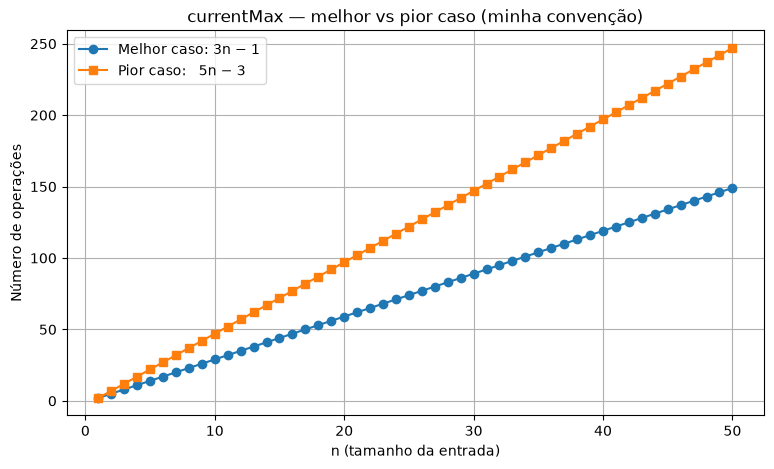

In [20]:

n = np.arange(1, 51)

melhor = 3*n - 1
pior   = 5*n - 3

plt.figure(figsize=(9, 5))
plt.plot(n, melhor, marker='o', label='Melhor caso: 3n − 1')
plt.plot(n, pior,   marker='s', label='Pior caso:   5n − 3')
plt.xlabel('n (tamanho da entrada)')
plt.ylabel('Número de operações')
plt.title('currentMax — melhor vs pior caso (minha convenção)')
plt.grid(True)
plt.legend()
plt.show()

# Análise algoritmo de Busca Sequencial

In [35]:
def busca_sequencial(vetor,alvo):
    i = 0
    while i < len(vetor) and vetor[i] != alvo:
        i += 1
    if i >= len(vetor):
        return -1    
    return i

In [36]:
print(vetor)
print(busca_sequencial(vetor,74))

[50, 84, 43, 74, 67]
3


## Melhor caso x Pior caso

* Melhor caso aqui é bem evidente e seria quando o alvo é exatamente o primeiro item do vetor

* Pior caso é quando o alvo ele não está no vetor dessa forma ele tem que checar todos os elementos

| Linha | Operação | Execuções (melhor) | Execuções (pior) |
|------:|----------|:------------------:|:----------------:|
| 1     |     1     |  1                  |1                  |
| 2     |      4    |   1                 | n                 |
| 3     |       2   |    0                |  n                |
| 4     |       1   |     1               |   1               |
| 5     |       1   |      0              |    1              |
| 6     |       1   |       1             |     0             |

Com isso:

* Melhor caso = **T(n) = 7**
* Pior caso = **T(n) = 6n + 3**

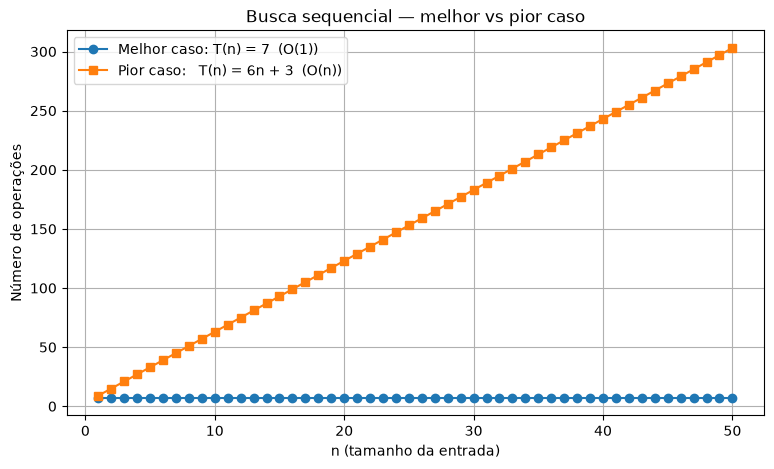

In [38]:
import matplotlib.pyplot as plt
import numpy as np

n = np.arange(1, 51)

melhor = np.full_like(n, 7)   # T(n) = 7 (constante)
pior   = 6*n + 3              # T(n) = 6n + 3

plt.figure(figsize=(9, 5))
plt.plot(n, melhor, marker='o', label='Melhor caso: T(n) = 7  (O(1))')
plt.plot(n, pior,   marker='s', label='Pior caso:   T(n) = 6n + 3  (O(n))')
plt.xlabel('n (tamanho da entrada)')
plt.ylabel('Número de operações')
plt.title('Busca sequencial — melhor vs pior caso')
plt.grid(True)
plt.legend()
plt.show()

# Análise para conta_ocorrencias

1) Identificando o melhor e o pior caso
2) Contagem de passos para o pior caso

In [39]:
def conta_ocorrencias(vetor,alvo):
    cont = 0
    for i in range(len(vetor)):
        if vetor[i] == alvo:
            cont += 1
    return cont

In [41]:
print(vetor)
print(conta_ocorrencias(vetor,74))

[50, 84, 43, 74, 67]
1


In [42]:
vetor_repetido = [1,1,12,3,4,5,7,10,1,3,1,5,1]
print(conta_ocorrencias(vetor_repetido,1))

5


1) Pior caso será quando todos os elementos são os elementos que queremos contar,melhor caso será quando o elemento que queremos contar não está na lista

| Linha | Operação | Execuções (pior) |
|------:|----------|:----------------:|
| 1     |1          |       1           |
| 2     | 1 ou 2(depende da convenção)         |n                  |
| 3     |2          |n                  |
| 4     | 2         |n                  |
| 5     |  1        | 1                 |

Isso nos dá : **T(n) = 6n + 2**
Novamente linear.